# Teaching a Neural Network to Invent Drug-Like Molecules

**What this notebook does, in one sentence:** it learns what ~250,000 real, drug-like molecules
look like, then *invents new ones* and steers them toward being more "drug-like" (a score called **QED**).

**The pipeline**

```
 real molecules ──► [ Encoder ] ──► a point on a "map of molecules" ──► [ Decoder ] ──► molecule again
   (text strings)     compress          (128 numbers = coordinates)         rebuild
                                              │
                                              └──► [ Property guesser ] ──► "predicted QED"
```

Once trained, we can **pick spots on the map, walk uphill toward higher QED, and decode what we find
into brand-new molecules.**

**How to use this notebook**
- **Just want to play?** Put the shared weights file (`molvae_qed.pt`) next to this notebook and
  *Run All*. Training is skipped automatically and you jump straight to the fun parts.
- **Want to train it yourself?** Delete the weights file (or set `RETRAIN = True`) and run all.
- **Laptop / dry run?** Set `QUICK_MODE = True` for a tiny, fast run (results will be poor; it just checks everything works).

## Ten-minute glossary (skim this first)

| Term | Plain-English meaning |
|---|---|
| **SMILES** | A way to write a molecule as a line of text. `CCO` = ethanol (two carbons and an oxygen). Parentheses show branches, digits show rings, lowercase letters are aromatic atoms. |
| **Token** | One "word" of a SMILES string, e.g. `C`, `Cl`, `(`, `=`, `[nH]`. The model reads tokens the way a language model reads words. |
| **Neural network** | A big adjustable function. Training = nudging millions of dials until its outputs get less wrong. |
| **Autoencoder** | Two networks back to back: an *encoder* that squeezes the input into a short list of numbers, and a *decoder* that tries to rebuild the original from that short list. Like summarizing a book and then rewriting it from the summary. |
| **VAE (Variational Autoencoder)** | An autoencoder with a twist: every molecule is squeezed into a *fuzzy cloud* rather than a single exact point, and clouds are encouraged to overlap into one smooth, well-behaved map. That smoothness is what lets us drop a pin on an *empty* spot and still decode something sensible. |
| **Latent space** | The "map" the encoder builds. Each molecule is a location (128 coordinates). Nearby locations ≈ similar molecules. |
| **`z`, `mu`, `logvar`** | `z` = a location on the map. The encoder outputs `mu` (centre of the cloud) and `logvar` (how wide the cloud is); we sample `z` from that cloud. |
| **KL divergence** | A penalty that keeps the clouds tidy and centred so the map stays smooth. Too strong → model ignores the map ("posterior collapse"). Too weak → the map has holes. |
| **QED** | *Quantitative Estimate of Drug-likeness*: a 0–1 score RDKit computes from properties like size, greasiness, and hydrogen-bond donors/acceptors. Higher = more like known oral drugs. It's a **heuristic**, not proof a molecule works as a drug. More info: https://optibrium.com/resources/quantitative-estimate-of-drug-likeness-in-stardrop/|
| **Latent optimization** | Instead of training the model to output high-QED molecules, we *move around the map* toward regions a small "QED guesser" says are good, then decode. |
| **RDKit** | The open-source chemistry toolkit that checks whether a string is a real molecule, draws it, and computes QED. |
| **TDC** | *Therapeutics Data Commons*: a library of ready-made drug-discovery datasets, including the ZINC molecule set used here. |

In [23]:
# Install dependencies (run once if in a fresh environment). Uncomment if needed.
# %pip install PyTDC rdkit torch scikit-learn matplotlib --quiet

In [2]:
import os, re, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display

from rdkit import Chem
from rdkit.Chem import QED, Draw
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')   # silence RDKit's chatty warnings

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## Settings

Everything you might want to tweak lives in this one cell.
If a saved weights file exists and `RETRAIN` is `False`, the model architecture and vocabulary are
read from that file, so your settings here can't accidentally mismatch the saved weights.

In [3]:
# ---- Run mode ----------------------------------------------------------
QUICK_MODE       = False             # True = tiny run just to check the notebook works
RETRAIN          = False             # True = ignore any saved weights and train from scratch
CHECKPOINT_PATH  = 'molvae_qed.pt'   # where weights are saved / loaded

# ---- Data --------------------------------------------------------------
MAX_TOKENS       = 80                # longest molecule (in tokens) we keep
MAX_TRAIN_MOLS   = 100_000           # subsample of ZINC used for training (None = all ~250k)
N_VAL            = 2000              # validation molecules
RANDOMIZE_SMILES = True              # data augmentation: show each molecule written in a random order

# ---- Model -------------------------------------------------------------
LATENT_DIM       = 128
EMBED_DIM        = 128
HIDDEN_DIM       = 384
NUM_LAYERS       = 2
WORD_DROPOUT     = 0.10              # randomly blank decoder inputs so it must rely on z

# ---- Training ----------------------------------------------------------
BATCH_SIZE       = 256
EPOCHS           = 20
LEARNING_RATE    = 1e-3
BETA_MAX         = 0.5               # max weight on the KL "tidiness" penalty
PROP_WEIGHT      = 1.0               # weight on the QED-guesser loss

if QUICK_MODE:
    MAX_TRAIN_MOLS, N_VAL, EPOCHS = 2000, 300, 2

# ---- Look for saved weights -------------------------------------------
ckpt = None
if os.path.exists(CHECKPOINT_PATH) and not RETRAIN:
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    MAX_TOKENS = ckpt['config']['max_tokens']
    print(f"✅ Found saved weights at '{CHECKPOINT_PATH}' - training will be skipped.")
else:
    print('No saved weights loaded - the model will be trained from scratch.')

No saved weights loaded - the model will be trained from scratch.


## 1. Load the data: the ZINC molecule library

ZINC is a large public catalogue of purchasable, drug-like molecules. TDC gives us ~250k of them,
each as a SMILES string, already split into **train / validation / test** piles.

In [4]:
from tdc.generation import MolGen

data = MolGen(name='ZINC')
split = data.get_split()

train_smiles = split['train']['smiles'].tolist()
valid_smiles = split['valid']['smiles'].tolist()

print(f'Train: {len(train_smiles):,} | Valid: {len(valid_smiles):,}')
print('Example SMILES:', train_smiles[:3])

Downloading...
100%|██████████| 11.8M/11.8M [00:02<00:00, 5.28MiB/s]
Loading...
Done!


Train: 174,618 | Valid: 24,946
Example SMILES: ['CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1', 'N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)cc2)cc1', 'CC[NH+](CC)[C@](C)(CC)[C@H](O)c1cscc1Br']


## 2. How a computer "reads" a molecule

A **SMILES** string is a molecule written as text. Below are a few real molecules from the dataset,
drawn by RDKit next to the text the model actually sees.

*Reading tip:* `c1ccccc1` is a benzene ring (`c` = aromatic carbon, the two `1`s open and close the ring),
`(...)` is a side branch, `=` is a double bond, `Cl`/`Br` are chlorine/bromine.

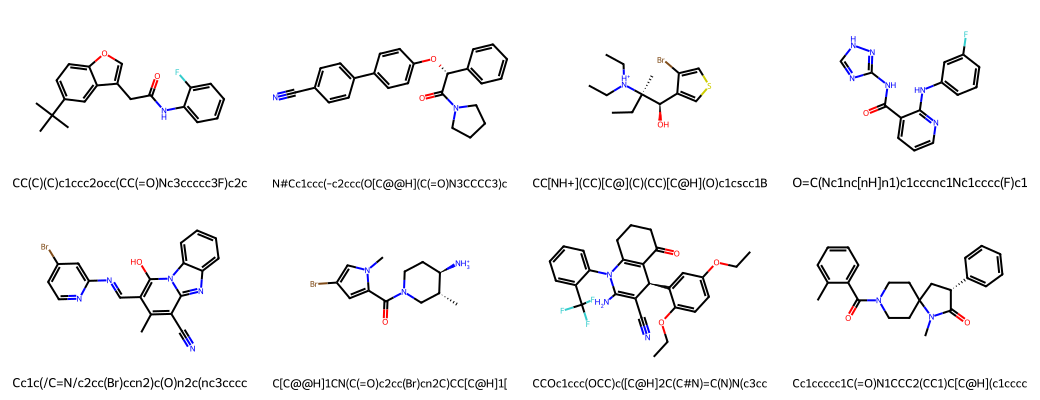

In [5]:
def show_mols(smiles_list, legends=None, per_row=4, size=(260, 200)):
    """Draw a grid of molecules from SMILES (silently skips strings RDKit can't parse)."""
    mols, labels = [], []
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi) if smi else None
        if m is not None and m.GetNumAtoms() > 0:
            mols.append(m)
            labels.append(legends[i] if legends else smi)
    if not mols:
        print('(nothing valid to draw)')
        return
    display(Draw.MolsToGridImage(mols, molsPerRow=per_row, subImgSize=size, legends=labels))

demo = train_smiles[:8]
show_mols(demo, legends=[f'{s[:38]}' for s in demo])

### Chopping SMILES into tokens

Neural networks need numbers, not letters. First we split each string into **tokens** (chemically
meaningful chunks: `Cl` stays together, `[nH]` stays together), then map each token to an integer ID.
Three special tokens are added: `<sos>` (start), `<eos>` (end), and `<pad>` (filler so every molecule
has the same length, like padding shorter rows in a spreadsheet).

In [6]:
SMILES_REGEX = re.compile(
    r"(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
)

def tokenize(smiles):
    return SMILES_REGEX.findall(smiles)

example = 'CC(=O)Nc1ccc(O)cc1Cl'
print('SMILES :', example)
print('Tokens :', tokenize(example))

SMILES : CC(=O)Nc1ccc(O)cc1Cl
Tokens : ['C', 'C', '(', '=', 'O', ')', 'N', 'c', '1', 'c', 'c', 'c', '(', 'O', ')', 'c', 'c', '1', 'Cl']


## 3. Clean the data and attach a "grade" (QED) to each molecule

1. **Canonicalize:** the same molecule can be written many ways (`OCC` = `CCO`). RDKit rewrites each
   into one standard spelling so duplicates are recognized.
2. **Drop** anything RDKit can't parse or that's too long for our model.
3. **Compute QED** for each molecule; this becomes the label the "QED guesser" learns to predict.

We also keep the full canonical training set so we can later check whether generated molecules are
*genuinely new* (novelty) rather than memorized.

In [7]:
def canon(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol is not None else None

def token_ok(smi):
    toks = tokenize(smi)
    return ''.join(toks) == smi and len(toks) <= MAX_TOKENS

def add_qed(smiles_list):
    out = []
    for smi in smiles_list:
        try:
            out.append((smi, QED.qed(Chem.MolFromSmiles(smi))))
        except Exception:
            pass
    return out

# canonical form of the ENTIRE training set (used later to measure novelty)
train_canon = [c for c in (canon(s) for s in train_smiles) if c]
train_canon_set = set(train_canon)

# subsample + length filter + QED label for the training set
pool = [c for c in train_canon if token_ok(c)]
random.shuffle(pool)
if MAX_TRAIN_MOLS is not None:
    pool = pool[:MAX_TRAIN_MOLS]
train_pairs = add_qed(pool)

val_pool = [c for c in (canon(s) for s in valid_smiles[:N_VAL * 3]) if c and token_ok(c)][:N_VAL]
valid_pairs = add_qed(val_pool)

print(f'Training molecules : {len(train_pairs):,}')
print(f'Validation molecules: {len(valid_pairs):,}')
print('Example (SMILES, QED):', train_pairs[0])

Training molecules : 100,000
Validation molecules: 2,000
Example (SMILES, QED): ('C[NH2+][C@H](C)c1ccnc(Sc2ncn[nH]2)c1', 0.8154500322530468)


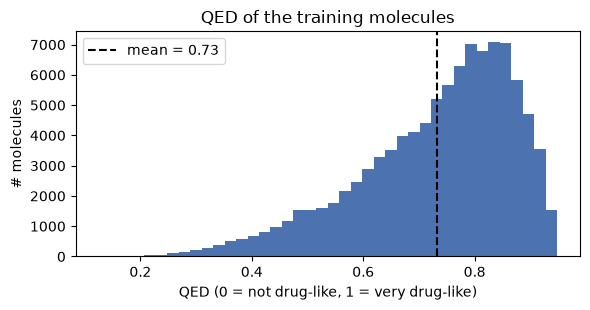

In [8]:
qeds_train = np.array([q for _, q in train_pairs])
plt.figure(figsize=(6, 3.2))
plt.hist(qeds_train, bins=40, color='#4C72B0')
plt.axvline(qeds_train.mean(), color='k', ls='--', label=f'mean = {qeds_train.mean():.2f}')
plt.xlabel('QED (0 = not drug-like, 1 = very drug-like)'); plt.ylabel('# molecules')
plt.title('QED of the training molecules'); plt.legend(); plt.tight_layout(); plt.show()

## 4. Vocabulary: token ↔ number lookup table

In [9]:
PAD, SOS, EOS = '<pad>', '<sos>', '<eos>'

if ckpt is not None:
    vocab = ckpt['vocab']
else:
    all_tokens = sorted({t for s, _ in train_pairs for t in tokenize(s)})
    vocab = [PAD, SOS, EOS] + all_tokens

stoi = {t: i for i, t in enumerate(vocab)}
itos = {i: t for t, i in stoi.items()}
PAD_ID, SOS_ID, EOS_ID = stoi[PAD], stoi[SOS], stoi[EOS]
VOCAB_SIZE = len(vocab)
SEQ_LEN = MAX_TOKENS + 2          # + <sos> and <eos>
print(f'Vocabulary size: {VOCAB_SIZE} tokens')
print(vocab)

def smiles_to_ids(smiles):
    """SMILES -> fixed-length list of token IDs, or None if it can't be encoded."""
    toks = tokenize(smiles)
    if ''.join(toks) != smiles or len(toks) > MAX_TOKENS or any(t not in stoi for t in toks):
        return None
    ids = [SOS_ID] + [stoi[t] for t in toks] + [EOS_ID]
    return ids + [PAD_ID] * (SEQ_LEN - len(ids))

def ids_to_smiles(ids):
    out = []
    for i in ids:
        t = itos[int(i)]
        if t == EOS:
            break
        if t in (PAD, SOS):
            continue
        out.append(t)
    return ''.join(out)

# (only matters when loading old weights with a different vocab) drop molecules we can't encode
train_pairs = [(s, q) for s, q in train_pairs if smiles_to_ids(s) is not None]
valid_pairs = [(s, q) for s, q in valid_pairs if smiles_to_ids(s) is not None]

ids = smiles_to_ids(example)
print('\nExample ->', ids[:16], '...')
print('Round trip ->', ids_to_smiles(ids))

Vocabulary size: 56 tokens
['<pad>', '<sos>', '<eos>', '#', '(', ')', '-', '/', '1', '2', '3', '4', '5', '6', '7', '8', '=', 'Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S', '[C@@H]', '[C@@]', '[C@H]', '[C@]', '[N+]', '[N-]', '[NH+]', '[NH-]', '[NH2+]', '[NH3+]', '[O+]', '[O-]', '[OH+]', '[P@@]', '[P@]', '[S+]', '[S-]', '[S@@+]', '[S@@]', '[S@]', '[n+]', '[n-]', '[nH+]', '[nH]', '[o+]', '\\', 'c', 'n', 'o', 's']

Example -> [1, 18, 18, 4, 16, 23, 5, 22, 52, 8, 52, 52, 52, 4, 23, 5] ...
Round trip -> CC(=O)Nc1ccc(O)cc1Cl


### Data augmentation: same molecule, many spellings

A molecule can be written starting from any atom. During training we show the model a **random valid
spelling** of each molecule every epoch (`RANDOMIZE_SMILES`). This is free extra data: the model learns
the *chemistry*, not one fixed spelling, which generally improves the validity and variety of what it generates.

In [10]:
class SmilesQEDDataset(Dataset):
    def __init__(self, pairs, randomize=False):
        self.smiles = [s for s, _ in pairs]
        self.qed = [q for _, q in pairs]
        self.randomize = randomize

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smi = self.smiles[idx]
        ids = None
        if self.randomize:
            mol = Chem.MolFromSmiles(smi)
            for _ in range(5):
                ids = smiles_to_ids(Chem.MolToSmiles(mol, canonical=False, doRandom=True))
                if ids is not None:
                    break
        if ids is None:
            ids = smiles_to_ids(smi)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.qed[idx], dtype=torch.float32)

train_loader = DataLoader(SmilesQEDDataset(train_pairs, randomize=RANDOMIZE_SMILES),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = DataLoader(SmilesQEDDataset(valid_pairs, randomize=False),
                          batch_size=BATCH_SIZE, shuffle=False)

# what randomization looks like for one molecule:
m = Chem.MolFromSmiles(train_pairs[0][0])
print('Canonical :', train_pairs[0][0])
for _ in range(3):
    print('Random    :', Chem.MolToSmiles(m, canonical=False, doRandom=True))

Canonical : C[NH2+][C@H](C)c1ccnc(Sc2ncn[nH]2)c1
Random    : c1nc(cc([C@H]([NH2+]C)C)c1)Sc1[nH]ncn1
Random    : n1c(cc(cc1)[C@@H](C)[NH2+]C)Sc1ncn[nH]1
Random    : n1[nH]c(nc1)Sc1cc([C@H]([NH2+]C)C)ccn1


## 5. The model: a Variational Autoencoder (VAE) with a QED guesser

```
                    ┌───────────────┐   mu, logvar   sample z     ┌───────────────┐
 "CC(=O)Nc1ccc.." ─►│    ENCODER    ├──────────────► ●  (128 #s)─►│    DECODER    ├─► "CC(=O)Nc1ccc.."
   (tokens)         │ reads L→R and │                 │           │ writes one    │      (rebuilt)
                    │ R→L (GRU)     │                 │           │ token at a    │
                    └───────────────┘                 │           │ time (GRU)    │
                                                      ▼           └───────────────┘
                                             ┌────────────────┐
                                             │ QED GUESSER    │─► predicted QED
                                             └────────────────┘
```

- **Encoder:** a *GRU* (a type of recurrent network that reads a sequence step by step and keeps a running
  "memory"). It reads the molecule in both directions and outputs `mu` and `logvar`.
- **Sampling (`z`):** we draw a point from the cloud `N(mu, exp(logvar))`. The randomness is what teaches
  the decoder to cope with *nearby* points and is why the map ends up smooth.
- **Decoder:** another GRU that writes the molecule token by token, like autocomplete. Improvement in this
  version: **`z` is fed in at every step**, not just the first, so the decoder can't "forget" the point it was
  given and can't get away with ignoring it.
- **QED guesser:** a tiny network that looks *only* at `z` and predicts the molecule's QED. Because it's trained
  jointly, the map organizes itself so QED changes smoothly across it. That's what lets us "walk uphill" later.

In [11]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, num_layers, pad_id):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                          bidirectional=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.to_mu = nn.Linear(2 * hidden_dim, latent_dim)
        self.to_logvar = nn.Linear(2 * hidden_dim, latent_dim)

    def forward(self, x):
        lengths = (x != self.pad_id).sum(1).cpu()            # ignore padding when reading
        packed = nn.utils.rnn.pack_padded_sequence(self.embed(x), lengths, batch_first=True,
                                                   enforce_sorted=False)
        _, h = self.gru(packed)                              # (layers*2, batch, hidden)
        h = torch.cat([h[-2], h[-1]], dim=-1)                # last layer, forward + backward
        return self.to_mu(h), self.to_logvar(h)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, num_layers, pad_id, word_dropout):
        super().__init__()
        self.hidden_dim, self.num_layers, self.pad_id = hidden_dim, num_layers, pad_id
        self.word_dropout = word_dropout
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_dim * num_layers)
        self.gru = nn.GRU(embed_dim + latent_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                          dropout=0.1 if num_layers > 1 else 0.0)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def init_hidden(self, z):
        h = torch.tanh(self.latent_to_hidden(z))
        return h.view(z.size(0), self.num_layers, self.hidden_dim).transpose(0, 1).contiguous()

    def forward(self, z, target_seq):
        """Teacher forcing: predict token t+1 from the true tokens up to t (used in training)."""
        dec_in = target_seq[:, :-1]
        if self.training and self.word_dropout > 0:
            drop = torch.rand(dec_in.shape, device=dec_in.device) < self.word_dropout
            drop[:, 0] = False                                # never blank the <sos>
            dec_in = dec_in.masked_fill(drop, self.pad_id)
        emb = self.embed(dec_in)
        z_rep = z.unsqueeze(1).expand(-1, emb.size(1), -1)
        out, _ = self.gru(torch.cat([emb, z_rep], dim=-1), self.init_hidden(z))
        return self.output(out)

    @torch.no_grad()
    def generate(self, z, max_len, temperature=0.0):
        """Write molecules from scratch. temperature=0 -> always the most likely token (greedy)."""
        B = z.size(0)
        tokens = torch.full((B, 1), SOS_ID, dtype=torch.long, device=z.device)
        h = self.init_hidden(z)
        finished = torch.zeros(B, dtype=torch.bool, device=z.device)
        outs = []
        for _ in range(max_len - 1):
            out, h = self.gru(torch.cat([self.embed(tokens), z.unsqueeze(1)], dim=-1), h)
            logits = self.output(out[:, -1])
            if temperature <= 0:
                nxt = logits.argmax(-1)
            else:
                nxt = torch.multinomial(F.softmax(logits / temperature, dim=-1), 1).squeeze(1)
            nxt = nxt.masked_fill(finished, PAD_ID)
            outs.append(nxt)
            finished |= (nxt == EOS_ID)
            tokens = nxt.unsqueeze(1)
            if finished.all():
                break
        return torch.stack(outs, dim=1)


class PropertyRegressor(nn.Module):
    """The 'QED guesser': looks only at a point on the map and predicts its QED."""
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent_dim, 128), nn.ReLU(),
                                 nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, z):
        return self.net(z).squeeze(-1)


class MolVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = Encoder(cfg['vocab_size'], cfg['embed_dim'], cfg['hidden_dim'],
                               cfg['latent_dim'], cfg['num_layers'], cfg['pad_id'])
        self.decoder = Decoder(cfg['vocab_size'], cfg['embed_dim'], cfg['hidden_dim'],
                               cfg['latent_dim'], cfg['num_layers'], cfg['pad_id'], cfg['word_dropout'])
        self.property_head = PropertyRegressor(cfg['latent_dim'])

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)   # z = centre + noise * width

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z, x), mu, logvar, self.property_head(z)


if ckpt is not None:
    cfg = ckpt['config']
else:
    cfg = dict(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
               num_layers=NUM_LAYERS, pad_id=PAD_ID, word_dropout=WORD_DROPOUT, max_tokens=MAX_TOKENS)
LATENT_DIM = cfg['latent_dim']

model = MolVAE(cfg).to(DEVICE)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Trainable parameters: 5,826,361


## 6. How the model is graded (the loss)

Every training step it's scored on three things at once:

1. **Reconstruction:** did the decoder rebuild the right tokens? (cross-entropy, like grading a game of telephone)
2. **KL divergence ("tidiness"):** are the clouds close to a standard bell curve centred at zero? Keeps the map smooth.
   We ramp its weight (`beta`) up slowly from 0 (**KL annealing**) so the decoder first learns to *use* the map
   before being pressured to keep it tidy; otherwise it can take the lazy route of ignoring `z`.
3. **QED guess error:** how far off was the QED guesser?

> Note: in the loss, KL is averaged per latent dimension (a convenience that keeps its scale comparable to the
> per-token reconstruction loss). In the logs and plots we report the **total KL in nats per molecule**, which is
> easier to interpret: it's roughly "how much information about the molecule the map location carries".

In [12]:
def kl_weight(step, total_steps, max_weight=None, warmup_frac=0.3):
    max_weight = BETA_MAX if max_weight is None else max_weight
    warmup = int(total_steps * warmup_frac)
    return max_weight if step >= warmup else max_weight * step / max(1, warmup)

def vae_loss(logits, target_seq, mu, logvar, prop_pred, prop_true, beta):
    recon = F.cross_entropy(logits.reshape(-1, logits.size(-1)), target_seq[:, 1:].reshape(-1),
                            ignore_index=PAD_ID)
    kl_total = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)).mean()   # nats / molecule
    prop = F.mse_loss(prop_pred, prop_true)
    total = recon + beta * kl_total / mu.size(1) + PROP_WEIGHT * prop
    return total, recon, kl_total, prop

## 7. Train the model - or load saved weights

- **If a weights file was found:** training is skipped and the saved model is loaded (takes seconds).
- **Otherwise:** we train, checking a held-out **validation set** every epoch, lowering the learning rate
  when validation stops improving, and keeping the **best** epoch's weights. When done, the weights are saved to
  `CHECKPOINT_PATH` so that nobody (including you, next time) has to train again.

In [13]:
history = {k: [] for k in ['train_total', 'train_recon', 'train_kl', 'train_prop',
                           'val_total', 'val_recon', 'val_kl', 'val_prop']}

def run_epoch(loader, train, step=0, total_steps=1):
    model.train(train)
    sums = np.zeros(4); n = 0
    with torch.set_grad_enabled(train):
        for x, prop_true in loader:
            x, prop_true = x.to(DEVICE), prop_true.to(DEVICE)
            beta = kl_weight(step, total_steps) if train else BETA_MAX
            logits, mu, logvar, prop_pred = model(x)
            loss, recon, kl, prop = vae_loss(logits, x, mu, logvar, prop_pred, prop_true, beta)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step(); step += 1
            sums += np.array([loss.item(), recon.item(), kl.item(), prop.item()]); n += 1
    return sums / max(n, 1), step

if ckpt is not None:
    model.load_state_dict(ckpt['model_state'])
    history = ckpt.get('history', history)
    print(f"Loaded weights (best epoch: {ckpt.get('best_epoch', '?')}).")
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
    total_steps = EPOCHS * len(train_loader)
    step, best_val, best_epoch, best_state = 0, float('inf'), 0, None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tr, step = run_epoch(train_loader, True, step, total_steps)
        va, _ = run_epoch(valid_loader, False)
        scheduler.step(va[0])
        for name, a, b in zip(['total', 'recon', 'kl', 'prop'], tr, va):
            history[f'train_{name}'].append(float(a)); history[f'val_{name}'].append(float(b))
        if va[0] < best_val:
            best_val, best_epoch, best_state = va[0], epoch, copy.deepcopy(model.state_dict())
        print(f'Epoch {epoch:2d}/{EPOCHS} | train recon {tr[1]:.3f} kl {tr[2]:5.1f} prop {tr[3]:.4f} '
              f'| val recon {va[1]:.3f} kl {va[2]:5.1f} prop {va[3]:.4f} '
              f'| beta {kl_weight(step, total_steps):.2f} | {time.time() - t0:.0f}s')

    model.load_state_dict(best_state)
    torch.save({'model_state': model.state_dict(), 'vocab': vocab, 'config': cfg,
                'history': history, 'best_epoch': best_epoch}, CHECKPOINT_PATH)
    print(f"\n💾 Saved best model (epoch {best_epoch}) to '{CHECKPOINT_PATH}' "
          f"({os.path.getsize(CHECKPOINT_PATH) / 1e6:.1f} MB) - share this file!")

model.eval();

Epoch  1/20 | train recon 1.215 kl  98.3 prop 0.0200 | val recon 0.673 kl 113.9 prop 0.0108 | beta 0.08 | 4887s
Epoch  2/20 | train recon 0.604 kl 111.0 prop 0.0092 | val recon 0.371 kl 105.9 prop 0.0079 | beta 0.17 | 2830s
Epoch  3/20 | train recon 0.405 kl 100.6 prop 0.0079 | val recon 0.271 kl  95.2 prop 0.0070 | beta 0.25 | 3216s
Epoch  4/20 | train recon 0.322 kl  88.9 prop 0.0073 | val recon 0.218 kl  83.4 prop 0.0066 | beta 0.33 | 2420s
Epoch  5/20 | train recon 0.282 kl  80.0 prop 0.0069 | val recon 0.197 kl  75.8 prop 0.0061 | beta 0.42 | 3847s
Epoch  6/20 | train recon 0.265 kl  73.2 prop 0.0068 | val recon 0.186 kl  70.5 prop 0.0065 | beta 0.50 | 2815s
Epoch  7/20 | train recon 0.249 kl  70.2 prop 0.0067 | val recon 0.166 kl  70.4 prop 0.0068 | beta 0.50 | 3245s
Epoch  8/20 | train recon 0.231 kl  69.9 prop 0.0065 | val recon 0.160 kl  70.4 prop 0.0066 | beta 0.50 | 5845s
Epoch  9/20 | train recon 0.215 kl  69.8 prop 0.0064 | val recon 0.147 kl  69.6 prop 0.0062 | beta 0.50 

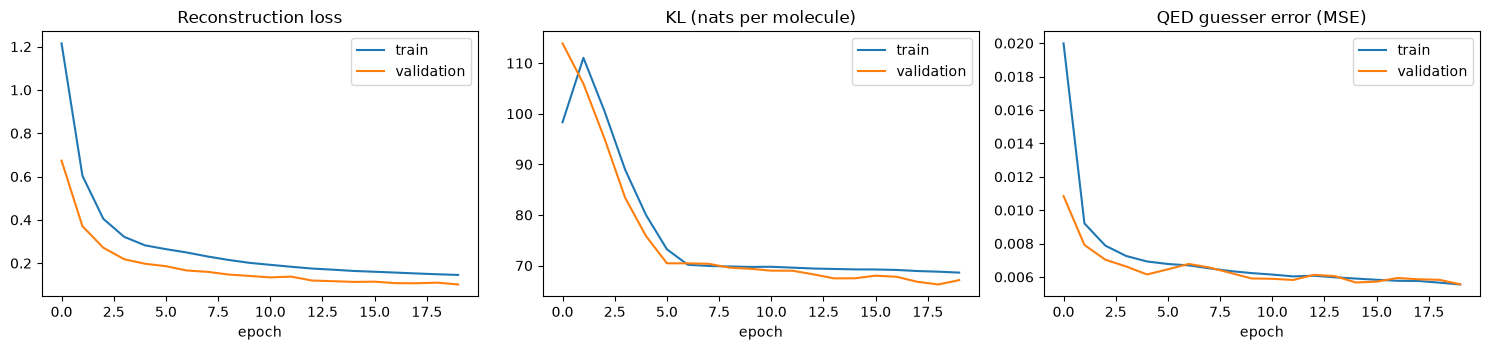

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, key, title in zip(axes, ['recon', 'kl', 'prop'],
                          ['Reconstruction loss', 'KL (nats per molecule)', 'QED guesser error (MSE)']):
    ax.plot(history[f'train_{key}'], label='train')
    ax.plot(history[f'val_{key}'], label='validation')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout(); plt.show()

## 8. Sanity check: can it rebuild molecules it has never seen?

Take validation molecules, squeeze each into the centre of its cloud (`mu`), and decode. If the map is any
good, we should get the **same molecule** back (possibly spelled differently, which is why we compare the
molecules, not the raw strings).

Valid molecules after decoding : 89.8%
Exactly the same molecule back : 76.0%


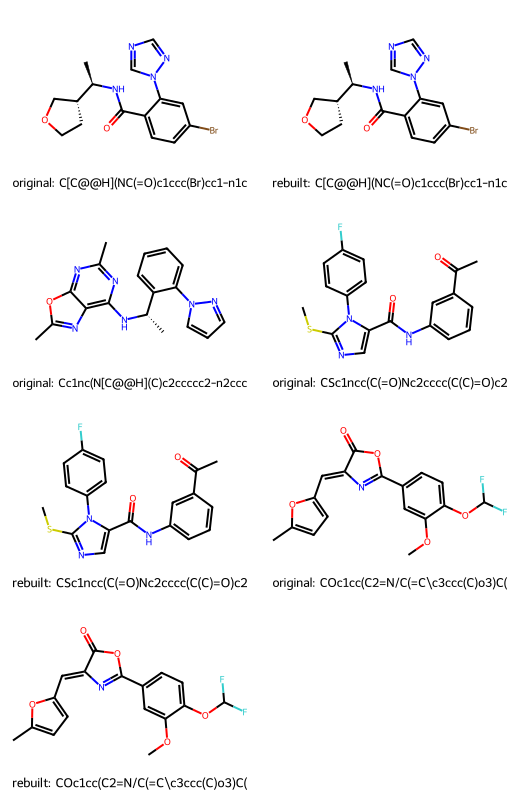

In [15]:
@torch.no_grad()
def encode_smiles_list(smiles_list):
    """Return (kept_smiles, mu) for all encodable SMILES."""
    kept, ids = [], []
    for s in smiles_list:
        i = smiles_to_ids(s)
        if i is not None:
            kept.append(s); ids.append(i)
    x = torch.tensor(ids, dtype=torch.long, device=DEVICE)
    mu, _ = model.encoder(x)
    return kept, mu

@torch.no_grad()
def decode_latents(z, temperature=0.0):
    return [ids_to_smiles(r) for r in model.decoder.generate(z, SEQ_LEN, temperature).cpu().numpy()]

def as_canonical(smi):
    m = Chem.MolFromSmiles(smi) if smi else None
    return Chem.MolToSmiles(m) if (m is not None and m.GetNumAtoms() > 0) else None

val_smiles = [s for s, _ in valid_pairs][:1000]
kept, mu = encode_smiles_list(val_smiles)
recon = decode_latents(mu)
same = np.mean([as_canonical(r) == s for r, s in zip(recon, kept)])
valid = np.mean([as_canonical(r) is not None for r in recon])
print(f'Valid molecules after decoding : {valid:.1%}')
print(f'Exactly the same molecule back : {same:.1%}')

pairs = [(s, r) for s, r in zip(kept[:4], recon[:4])]
show_mols([x for p in pairs for x in p],
          legends=[f'{tag}: {x[:30]}' for p in pairs for tag, x in zip(['original', 'rebuilt'], p)], per_row=2)

## 9. Look at the map

We can't draw 128 dimensions, so we squash them to 2 with **PCA** (a standard method that keeps the directions
with the most variation). Left: every dot is a molecule, coloured by its **true** QED. If the map is
organized around drug-likeness, you'll see colour trends across it. Right: how well the QED guesser's predictions
(from location alone) match the truth.

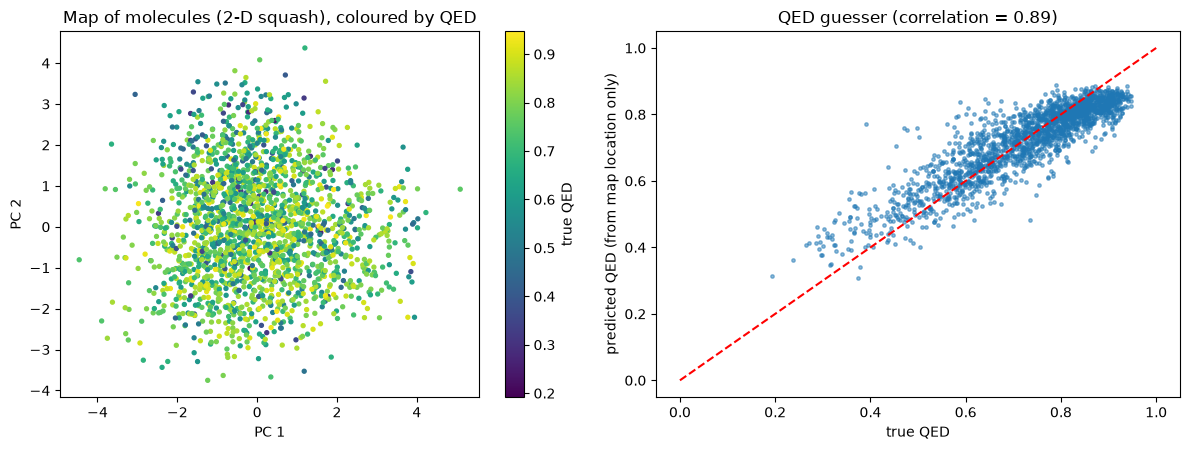

In [16]:
from sklearn.decomposition import PCA

kept_v, mu_v = encode_smiles_list([s for s, _ in valid_pairs])
qed_v = np.array([q for s, q in valid_pairs if smiles_to_ids(s) is not None])
with torch.no_grad():
    pred_v = model.property_head(mu_v).cpu().numpy()
xy = PCA(n_components=2).fit_transform(mu_v.cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sc = axes[0].scatter(xy[:, 0], xy[:, 1], c=qed_v, cmap='viridis', s=8)
plt.colorbar(sc, ax=axes[0], label='true QED')
axes[0].set_title('Map of molecules (2-D squash), coloured by QED')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[1].scatter(qed_v, pred_v, s=6, alpha=0.5)
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_xlabel('true QED'); axes[1].set_ylabel('predicted QED (from map location only)')
axes[1].set_title(f'QED guesser (correlation = {np.corrcoef(qed_v, pred_v)[0, 1]:.2f})')
plt.tight_layout(); plt.show()

## 10. The magic trick: walking between two molecules

Pick two molecules, then take small steps along the straight line between their locations on the map and decode
each stop. A good VAE morphs smoothly from one to the other. This works *because* of the "fuzzy cloud" training.

start: NC(=O)C1CCN(S(=O)(=O)c2cc(Cl)c(Cl)cc2Cl)CC1
end  : CC(=O)N(C)C[C@H](O)COc1ccccc1C(F)(F)F


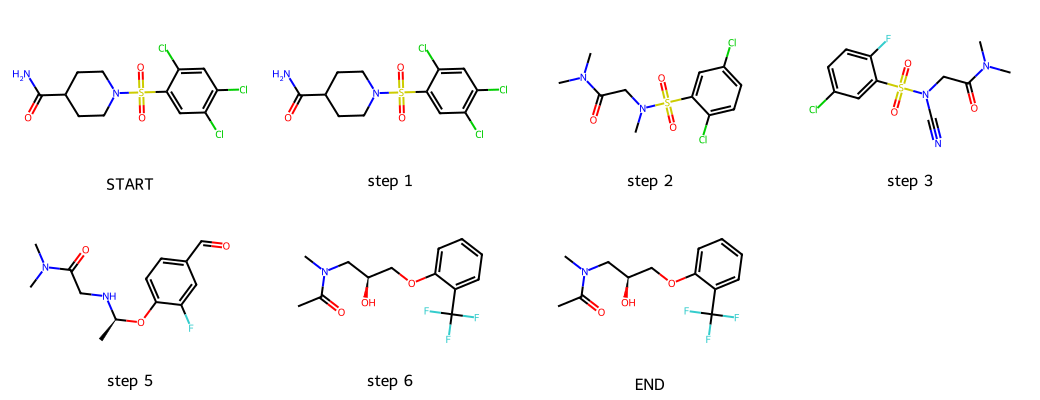

In [17]:
def interpolate(smi_a, smi_b, steps=8):
    _, m = encode_smiles_list([smi_a, smi_b])
    t = torch.linspace(0, 1, steps, device=DEVICE).unsqueeze(1)
    z = m[0] * (1 - t) + m[1] * t
    return decode_latents(z)

rng = random.Random(3)
a, b = rng.sample([s for s, _ in valid_pairs], 2)
path = interpolate(a, b, steps=8)
legends = ['START'] + [f'step {i}' for i in range(1, 7)] + ['END']
print('start:', a); print('end  :', b)
show_mols(path, legends=legends, per_row=4)

## 11. Inventing molecules with a target property

**The recipe (latent optimization):**

1. Drop random pins on the map (sample `z` from a standard bell curve).
2. **Walk uphill:** nudge each pin in whatever direction raises the QED guesser's prediction. (This is
   *gradient ascent* on `z`, the same idea as training, except we're moving the pin rather than the model.)
3. Decode the pins into molecules and check their **real** QED with RDKit.

Two safety rails added in this version:
- **Stop at a target** (`target_qed`): once the guesser is satisfied, stop pushing. Otherwise it can "hack" the
  guesser by pushing into nonsense regions where the guesser is wrong.
- **Stay near home** (`prior_weight`): a small penalty for wandering far from where the map was trained. Far from home,
  the decoder emits invalid molecules.

**How we score the results**
- **Validity:** fraction of outputs that are real molecules (the decoder can emit gibberish; nothing forces valid chemistry).
- **Uniqueness:** fraction of valid ones that are different from each other.
- **Novelty:** fraction of unique ones not in the training data (i.e. actually *new*).
- **QED:** the real, RDKit-computed score of the valid molecules.

In [18]:
MIN_HEAVY_ATOMS = 5   # ignore degenerate outputs (e.g. an empty string counts as "parseable" but isn't a molecule)

def optimize_latents(z0, steps=50, lr=0.05, prior_weight=0.1, target_qed=0.95):
    z = z0.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        gap = (target_qed - model.property_head(z)).clamp(min=0)          # 0 once the target is reached
        loss = (gap + prior_weight * z.pow(2).mean(dim=1)).sum()
        loss.backward(); opt.step()
    return z.detach()

def generate(n=500, steps=50, temperature=0.0, **opt_kwargs):
    z = torch.randn(n, LATENT_DIM, device=DEVICE)
    if steps > 0:
        with torch.enable_grad():
            z = optimize_latents(z, steps=steps, **opt_kwargs)
    return decode_latents(z, temperature)

def evaluate_generated(smiles_list):
    valid = []
    for smi in smiles_list:
        m = Chem.MolFromSmiles(smi) if smi else None
        if m is not None and m.GetNumHeavyAtoms() >= MIN_HEAVY_ATOMS:
            valid.append(Chem.MolToSmiles(m))
    unique = sorted(set(valid))
    novel = [s for s in unique if s not in train_canon_set]
    qed_by = {s: QED.qed(Chem.MolFromSmiles(s)) for s in unique}
    q = np.array([qed_by[s] for s in valid]) if valid else np.array([0.0])
    n = len(smiles_list)
    return {
        'validity': len(valid) / n,
        'uniqueness': len(unique) / max(len(valid), 1),
        'novelty': len(novel) / max(len(unique), 1),
        'avg_qed': float(q.mean()),
        'frac_qed>0.9': float((q > 0.9).mean()),
    }, qed_by, set(novel), q

def show_metrics(name, m):
    print(f"{name:<28} validity {m['validity']:.1%} | unique {m['uniqueness']:.1%} | "
          f"novel {m['novelty']:.1%} | mean QED {m['avg_qed']:.3f} | QED>0.9: {m['frac_qed>0.9']:.1%}")

Training-set mean QED: 0.732

Random pins (no steering)    validity 42.6% | unique 100.0% | novel 100.0% | mean QED 0.727 | QED>0.9: 6.1%
Steered (50 steps uphill)    validity 62.5% | unique 100.0% | novel 100.0% | mean QED 0.843 | QED>0.9: 25.0%


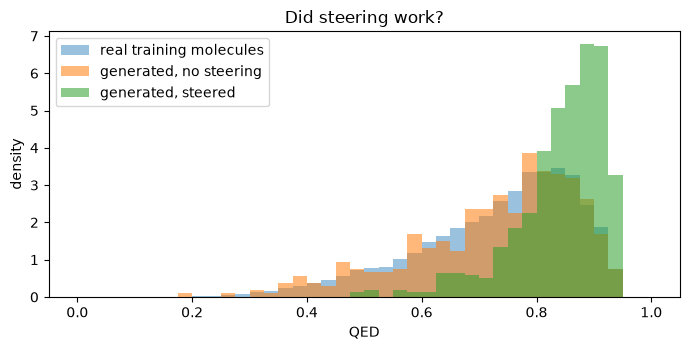

In [19]:
N_GEN, OPT_STEPS = 1000, 50

base_m,  base_by,  base_novel,  base_q  = evaluate_generated(generate(N_GEN, steps=0))
opt_m,   opt_by,   opt_novel,   opt_q   = evaluate_generated(generate(N_GEN, steps=OPT_STEPS))

print(f'Training-set mean QED: {qeds_train.mean():.3f}\n')
show_metrics('Random pins (no steering)', base_m)
show_metrics(f'Steered ({OPT_STEPS} steps uphill)', opt_m)

plt.figure(figsize=(7, 3.6))
bins = np.linspace(0, 1, 41)
plt.hist(qeds_train, bins=bins, density=True, alpha=0.45, label='real training molecules')
plt.hist(base_q, bins=bins, density=True, alpha=0.55, label='generated, no steering')
plt.hist(opt_q, bins=bins, density=True, alpha=0.55, label='generated, steered')
plt.xlabel('QED'); plt.ylabel('density'); plt.legend(); plt.title('Did steering work?')
plt.tight_layout(); plt.show()

### The trade-off: how far uphill should we walk?

More steps → higher QED, but walk too far and the pins leave the well-trained part of the map, so **validity
and novelty can drop**. This sweep makes that trade-off visible.

  0 steps                    validity 44.8% | unique 100.0% | novel 100.0% | mean QED 0.710 | QED>0.9: 2.7%
 10 steps                    validity 50.0% | unique 100.0% | novel 100.0% | mean QED 0.809 | QED>0.9: 16.8%
 25 steps                    validity 54.2% | unique 100.0% | novel 100.0% | mean QED 0.830 | QED>0.9: 18.5%
 50 steps                    validity 64.0% | unique 100.0% | novel 100.0% | mean QED 0.839 | QED>0.9: 23.1%
100 steps                    validity 65.2% | unique 100.0% | novel 100.0% | mean QED 0.840 | QED>0.9: 21.5%
200 steps                    validity 78.4% | unique 91.3% | novel 100.0% | mean QED 0.844 | QED>0.9: 23.0%


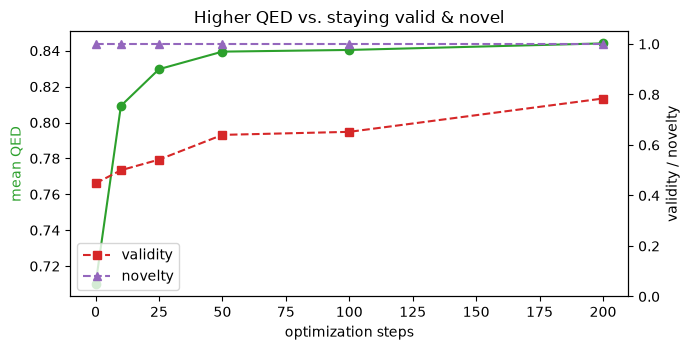

In [20]:
sweep_steps = [0, 10, 25, 50, 100, 200]
rows = []
for s in sweep_steps:
    m, *_ = evaluate_generated(generate(500, steps=s))
    rows.append(m)
    show_metrics(f'{s:>3} steps', m)

fig, ax1 = plt.subplots(figsize=(7, 3.6))
ax1.plot(sweep_steps, [r['avg_qed'] for r in rows], 'o-', color='tab:green', label='mean QED')
ax1.set_xlabel('optimization steps'); ax1.set_ylabel('mean QED', color='tab:green')
ax2 = ax1.twinx()
ax2.plot(sweep_steps, [r['validity'] for r in rows], 's--', color='tab:red', label='validity')
ax2.plot(sweep_steps, [r['novelty'] for r in rows], '^--', color='tab:purple', label='novelty')
ax2.set_ylabel('validity / novelty'); ax2.set_ylim(0, 1.05); ax2.legend(loc='lower left')
plt.title('Higher QED vs. staying valid & novel'); plt.tight_layout(); plt.show()

### The best molecules it invented

Below: the highest-QED molecules from the steered run that are **valid and not in the training data**.

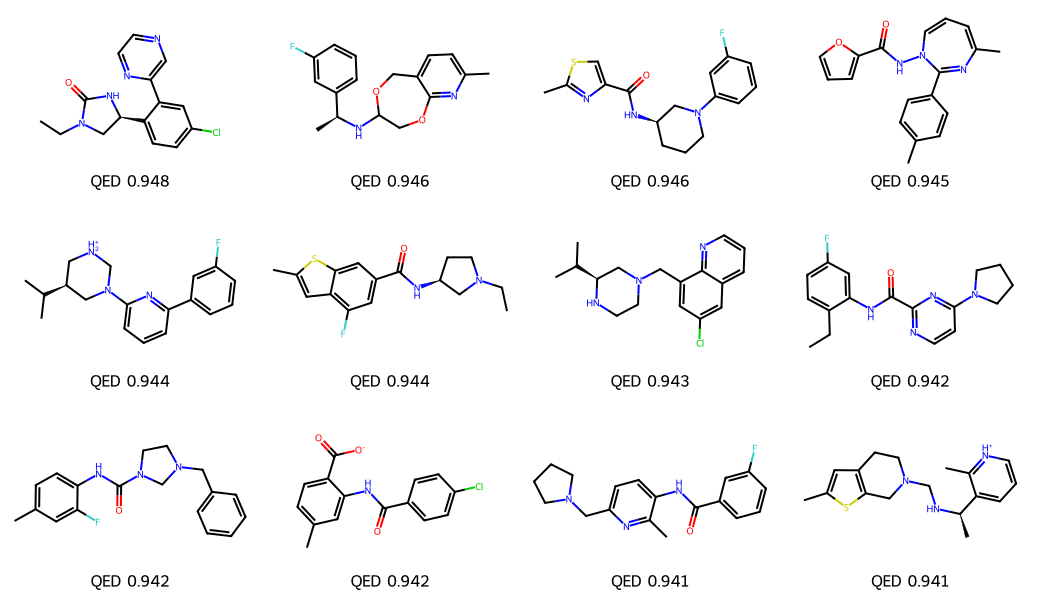

In [21]:
best = sorted([s for s in opt_novel], key=lambda s: -opt_by[s])[:12]
show_mols(best, legends=[f'QED {opt_by[s]:.3f}' for s in best], per_row=4)

## 12. Playground

Type in any molecule (as SMILES) and:
- `neighbors(smiles)` shows molecules that live *near it* on the map (raise `noise` to wander farther);
- `improve(smiles)` walks uphill toward higher QED and shows before vs. after.

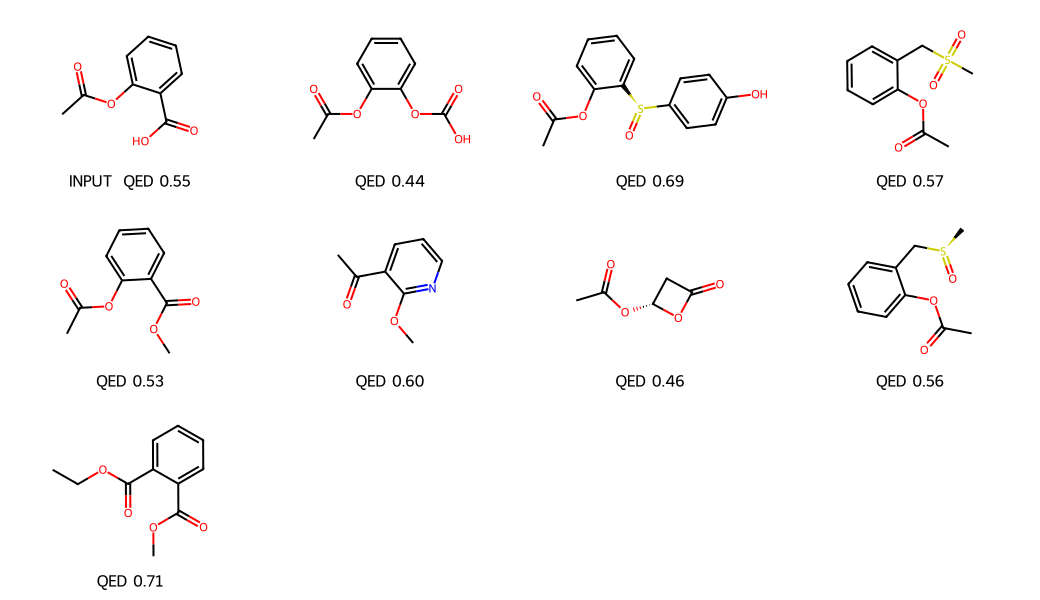

before: CC(=O)Oc1ccccc1C(=O)O (QED 0.550)
after : CC(=O)Nc1ccccc1COc1ccc(Cl)cc1 (QED 0.920)


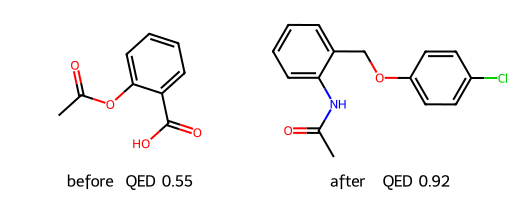

In [22]:
def true_qed(smi):
    return QED.qed(Chem.MolFromSmiles(smi))

def neighbors(smiles, n=8, noise=0.5):
    smiles = as_canonical(smiles)
    kept, mu = encode_smiles_list([smiles])
    if not kept:
        raise ValueError('That molecule uses tokens/length the model does not know.')
    z = mu.repeat(n, 1) + noise * torch.randn(n, mu.size(1), device=DEVICE)
    outs = decode_latents(z)
    outs = [smiles] + [o for o in dict.fromkeys(outs) if as_canonical(o) not in (None, smiles)]
    labels = [('INPUT  ' if i == 0 else '') + f'QED {true_qed(as_canonical(o)):.2f}' if as_canonical(o) else 'invalid'
              for i, o in enumerate(outs)]
    show_mols(outs, legends=labels, per_row=4)

def improve(smiles, steps=30, target_qed=0.95, prior_weight=0.1):
    smiles = as_canonical(smiles)
    kept, mu = encode_smiles_list([smiles])
    if not kept:
        raise ValueError('That molecule uses tokens/length the model does not know.')
    with torch.enable_grad():
        z = optimize_latents(mu, steps=steps, target_qed=target_qed, prior_weight=prior_weight)
    out = decode_latents(z)[0]
    print('before:', smiles, f'(QED {true_qed(smiles):.3f})')
    if as_canonical(out):
        print('after :', as_canonical(out), f'(QED {true_qed(as_canonical(out)):.3f})')
        show_mols([smiles, out], legends=[f'before  QED {true_qed(smiles):.2f}',
                                         f'after   QED {true_qed(as_canonical(out)):.2f}'], per_row=2)
    else:
        print('after : (decoded to an invalid string - try fewer steps or a larger prior_weight)')

MY_SMILES = 'CC(=O)Oc1ccccc1C(=O)O'   # aspirin - change me!
neighbors(MY_SMILES, n=12, noise=0.5)
improve(MY_SMILES)

## 13. Caveats, honest limitations, and where to go next

**Caveats**
- **QED is a rule-of-thumb**, not efficacy. A high-QED molecule is not necessarily a good, safe, or *makeable* drug.
  Nothing here checks synthesizability, toxicity, or binding to any protein target.
- **SMILES VAEs produce some invalid strings.** Validity is measured, not guaranteed. Graph-based models (e.g. JT-VAE) build valid molecules by construction.
- Novelty is measured against ZINC's training split only; a "new" molecule might exist in other databases.
- Numbers depend on training length, data subset size, and random seeds.

**Ideas to extend it**
- Swap QED for another RDKit property (`Crippen.MolLogP`, `Descriptors.MolWt`, synthetic accessibility) or a
  trained predictor (e.g. a toxicity or binding model): only the label column and target change.
- Optimize **several** properties at once (e.g. high QED *and* logP in a range).
- Try a **conditional VAE** (feed the desired property into the decoder) instead of post-hoc optimization.
- Improve validity with **beam search / temperature sampling**, a larger latent space, or training on the full 250k.
- Add a **novelty/diversity term** so the optimizer doesn't collapse many pins onto the same molecule.

**Sharing:** send collaborators this notebook **plus `molvae_qed.pt`**. Put them in the same folder and *Run All*;
no retraining needed.

*Built with PyTorch, RDKit, and Therapeutics Data Commons (TDC).*